# 10k Occupancy Investigation

Investigate why there is a drop in counts in S-phase. Is this a modeling/numerical issue?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [179]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 3
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, (20000, 30000), log=False)


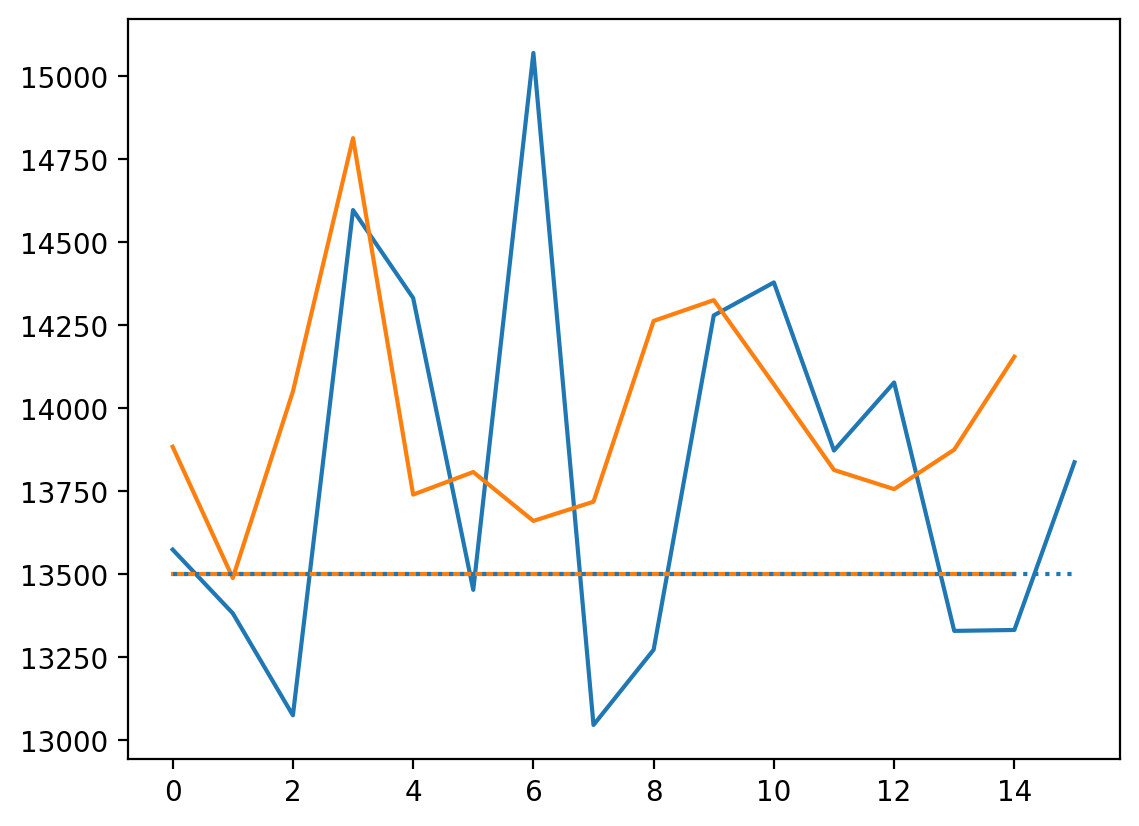

In [197]:
# Test a correction to G in which we enforce all timepoints to be of equal occupancy
G1 = genome_deconvolution.combined_model.chrom1_model.uncorrected_G
G2 = genome_deconvolution.combined_model.chrom2_model.uncorrected_G

corrected_G1 = G1 / G1.sum(axis=1).reshape((-1, 1)) * 13500
corrected_G2 = G2 / G2.sum(axis=1).reshape((-1, 1)) * 13500

g1_color = plt.get_cmap('tab10')(0)
g2_color = plt.get_cmap('tab10')(1)

plt.plot(G1.sum(axis=1), color=g1_color)
plt.plot(G2.sum(axis=1), color=g2_color)

plt.plot(corrected_G2.sum(axis=1), color=g2_color, ls='solid')
plt.plot(corrected_G1.sum(axis=1), color=g1_color, ls='dotted')

In [198]:
genome_deconvolution.deconvolve(corrected_G1, corrected_G2)

Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 26000)
Deconvolving with gamma=0.0066
0/26000 - 00:00:00.136
500/26000 - 00:00:33.791
1000/26000 - 00:01:07.332
1500/26000 - 00:01:40.898
2000/26000 - 00:02:14.823
2500/26000 - 00:02:49.258
3000/26000 - 00:03:22.798
3500/26000 - 00:03:55.992
4000/26000 - 00:04:29.958
4500/26000 - 00:05:01.399
5000/26000 - 00:05:32.805
5500/26000 - 00:06:03.231
6000/26000 - 00:06:34.381
6500/26000 - 00:07:05.087
7000/26000 - 00:07:35.546
7500/26000 - 00:08:06.264
8000/26000 - 00:08:36.992
8500/26000 - 00:09:06.994
9000/26000 - 00:09:37.093
9500/26000 - 00:10:07.302
10000/26000 - 00:10:37.276
10500/26000 - 00:11:07.144
11000/26000 - 00:11:37.044
11500/26000 - 00:12:06.916
12000/26000 - 00:12:36.887
12500/26000 - 00:13:06.790
13000/26000 - 00:13:37.132
13500/26000 - 00:14:07.176
14000/26000 - 00:14:37.352
14500/26000 - 00:15:07.782
15000/26000 - 00:15:38.356
15500/26000 - 00:16:09.017
16000/26000 - 00:16:39.952
165

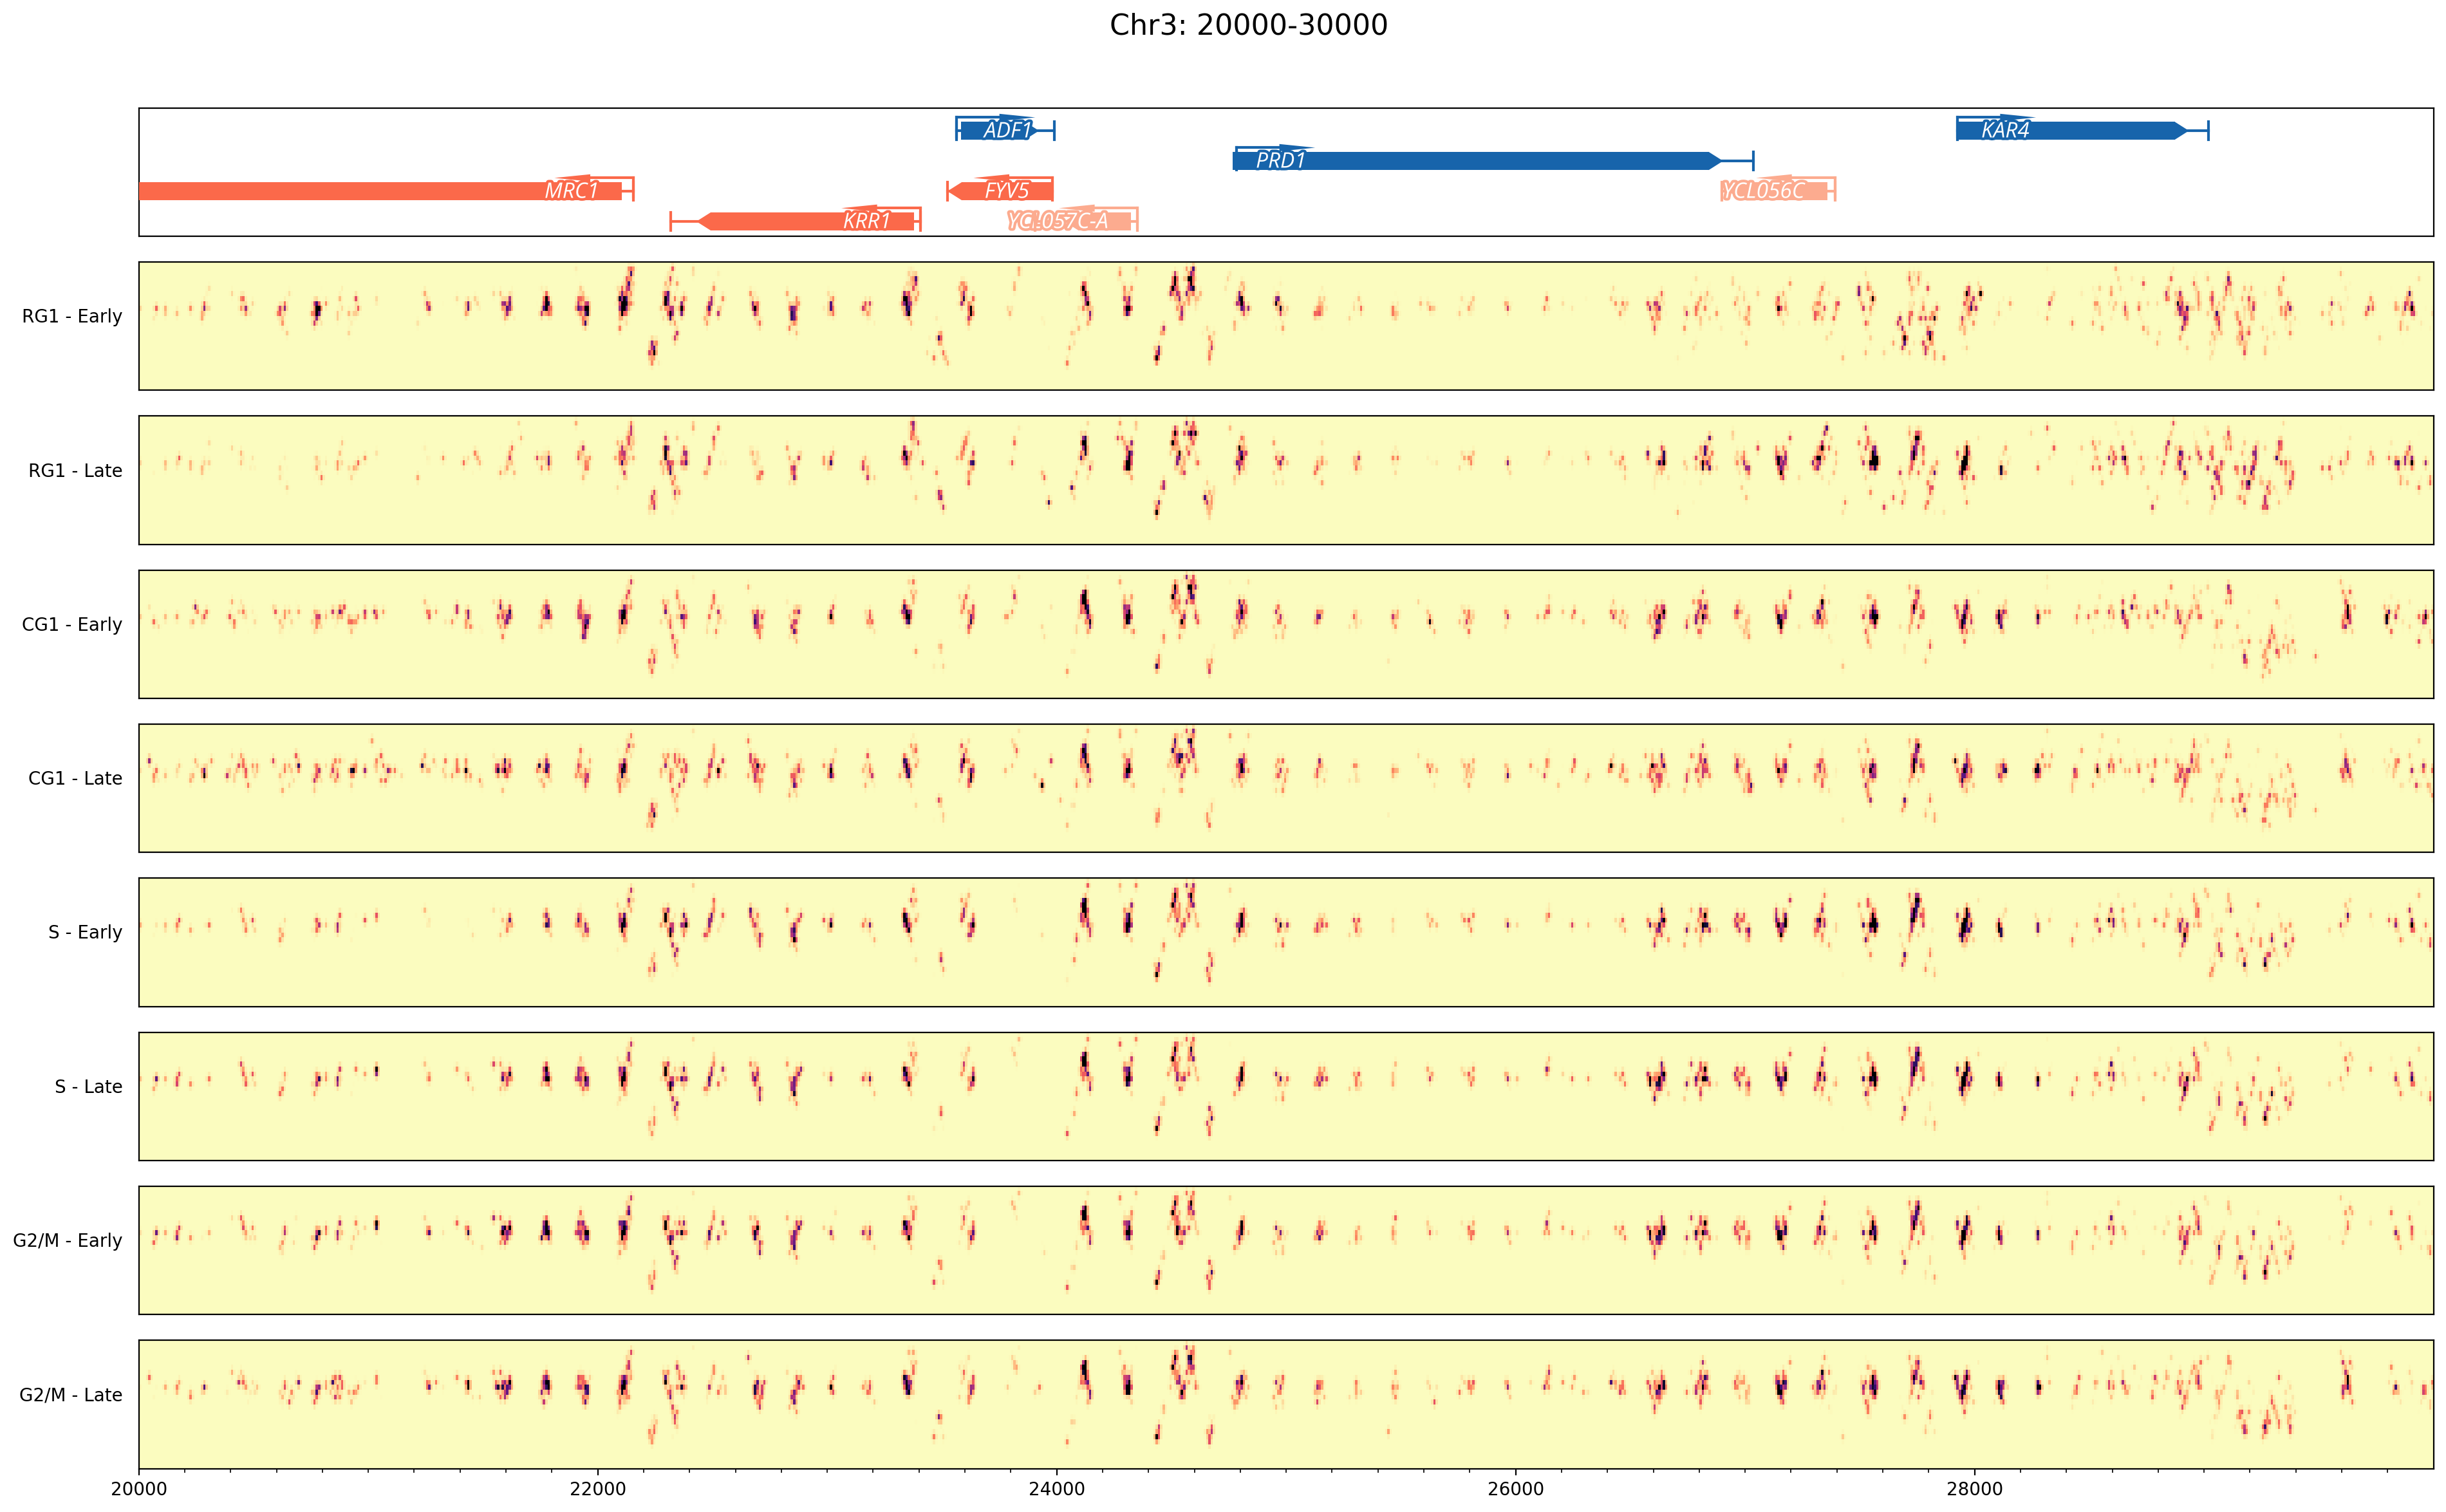

In [201]:
# Regardless if this deconvolution resolves the drop out of reads in S phase, 
# the copy correction procedure needs to be examined
fig = genome_deconvolution.plot_deconvolved_result(vmax=5)

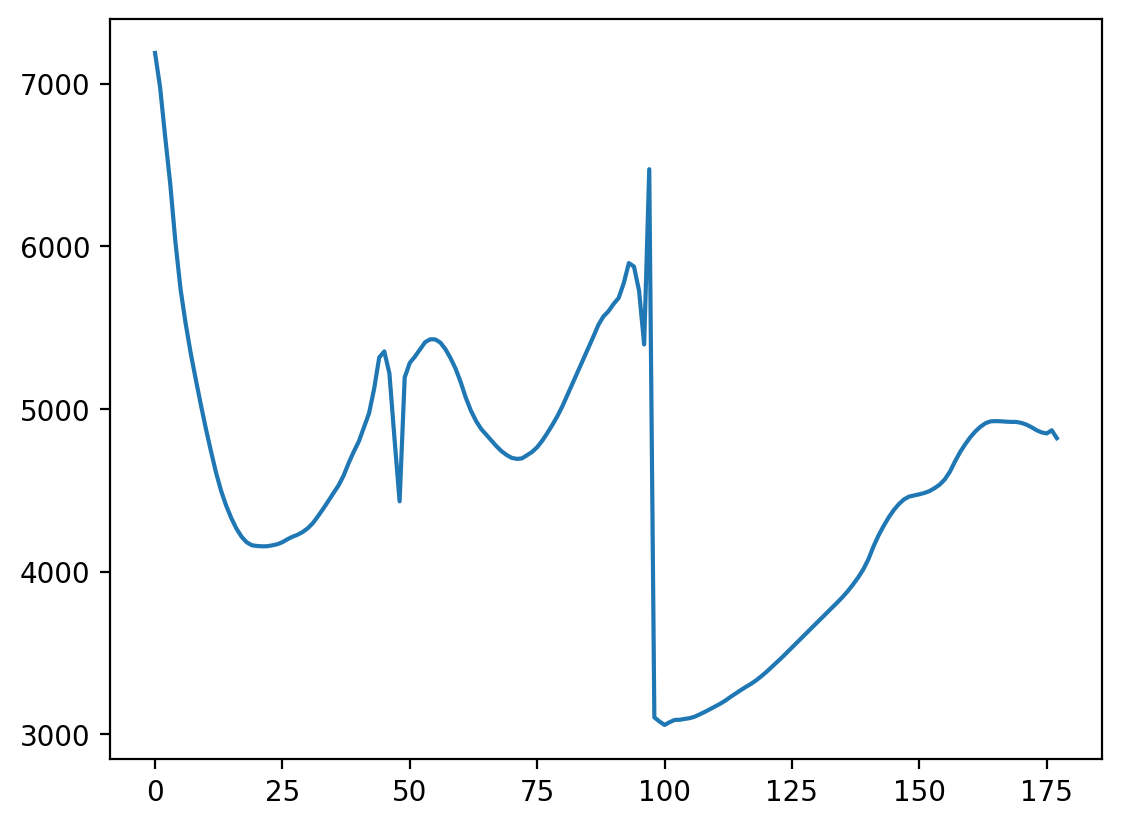

In [204]:
f_val = genome_deconvolution.combined_model.deconvolved_f_value
plt.plot(f_val.sum(axis=1))

# Continued observation of large drop off in reads during S phase.
